## Proteomics–Transcriptomics Correlation for Syn1

- Proteomics use IBAQ (Intensity-based Absolute Quantification)  
  IBAQ as proxy of protein copy number;  
  Yet not necessarily scale w. true protein copy number linearly;

- Pearson r of .6 between Illumina and proteome; of .5 between PacBio and proteome.
- For only cytosolic proteins, the r is .67, slightly higher.

In [1]:
import pandas as pd
import numpy as np
import os
import pysam
from typing import Dict, List, Tuple, Optional


**Load Syn1 Transcriptome**

In [2]:
Syn1_Transcriptomics_CSV = "./syn1_Illumina_PacBio_TPM_profiles.csv"
genes = pd.read_csv(Syn1_Transcriptomics_CSV)

**Load Syn1 Proteome**

In [3]:
import pandas as pd
import numpy as np

PROTEOME_FOLDER = "/data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/Proteomics/"

prot = pd.read_csv(PROTEOME_FOLDER + 'syn1_proteomics_localization_2026.csv')

print(f"Columns in proteomics data: {prot.columns.tolist()}")

print(f"Localization categories: {set(prot['ptn_localization'].dropna().unique())}")

Columns in proteomics data: ['chrom', 'feature', 'start0', 'end0', 'strand', 'locus_tag', 'gene_name', 'rna_type', 'gene_product', 'protein_mw_Da', 'iPM_rep1', 'iPM_rep2', 'iPM_rep3', 'iPM_mean', 'iPM_CV', 'ptn_copy_number', 'TMRs', 'topo_regions', 'protein_length', 'signalP', 'ptn_localization']
Localization categories: {'lipoprotein', 'Non_proteins', 'extracellular', 'membrane', 'cytoplasmic'}


**Map proteomics iPM onto the `genes` dataframe**

In [4]:
# Build mapping from locus_tag to iPM values
iPM_map = prot.set_index('locus_tag')[['iPM_rep1', 'iPM_rep2', 'iPM_rep3', 'iPM_mean', 'iPM_CV', 'ptn_localization']]

# Map onto genes dataframe
for col in iPM_map.columns:
    genes[col] = genes['locus_tag'].map(iPM_map[col])

detected = genes['iPM_mean'].notna().sum()
total = len(genes[genes['rna_type'] == 'mRNA'])
print(f'Total genes in dataframe: {total}')
print(f'Genes with proteomics data: {detected} ({detected/total*100:.1f}%)')
print(f'Genes without proteomics:   {total - detected}')

Total genes in dataframe: 828
Genes with proteomics data: 739 (89.3%)
Genes without proteomics:   89


### **Spearman correlation**

In [5]:
from scipy.stats import spearmanr, pearsonr

# transcriptome_col = "PacBio_sense_TPM" # PacBio
transcriptome_col = "avg_sense_TPM" # Illumina

print(f"Correlation between iPM_mean and {transcriptome_col}:")
# Filter to genes with both measurements > 0
mask = (genes['iPM_mean'] > 0) & (genes[transcriptome_col] > 0)


full_categories = set(genes['ptn_localization'].dropna().unique())
print(f"Full localization categories: {', '.join(full_categories)}")
loc_categories = ['cytoplasmic']
ptn_loc_mask = genes['ptn_localization'].isin(loc_categories)
print(f"Correlation for {', '.join(loc_categories)}:")


mask = mask & ptn_loc_mask
corr_df = genes.loc[mask].copy()

corr_df['log10_iPM'] = np.log10(corr_df['iPM_mean'])
corr_df['log10_TPM'] = np.log10(corr_df[transcriptome_col])

rho, p_spearman = spearmanr(corr_df['log10_iPM'], corr_df['log10_TPM'])
r, p_pearson = pearsonr(corr_df['log10_iPM'], corr_df['log10_TPM'])
print(f'N genes (both iPM > 0 & TPM > 0 & {", ".join(loc_categories)}): {len(corr_df)}')
print(f'Spearman ρ = {rho:.4f}  (p = {p_spearman:.2e})')
print(f'Pearson  r = {r:.4f}  (p = {p_pearson:.2e})')

Correlation between iPM_mean and avg_sense_TPM:
Full localization categories: lipoprotein, Non_proteins, extracellular, membrane, cytoplasmic
Correlation for cytoplasmic:
N genes (both iPM > 0 & TPM > 0 & cytoplasmic): 519
Spearman ρ = 0.7392  (p = 8.03e-91)
Pearson  r = 0.6720  (p = 1.91e-69)


**Scatter plot — log10(iPM) vs log10(TPM)**

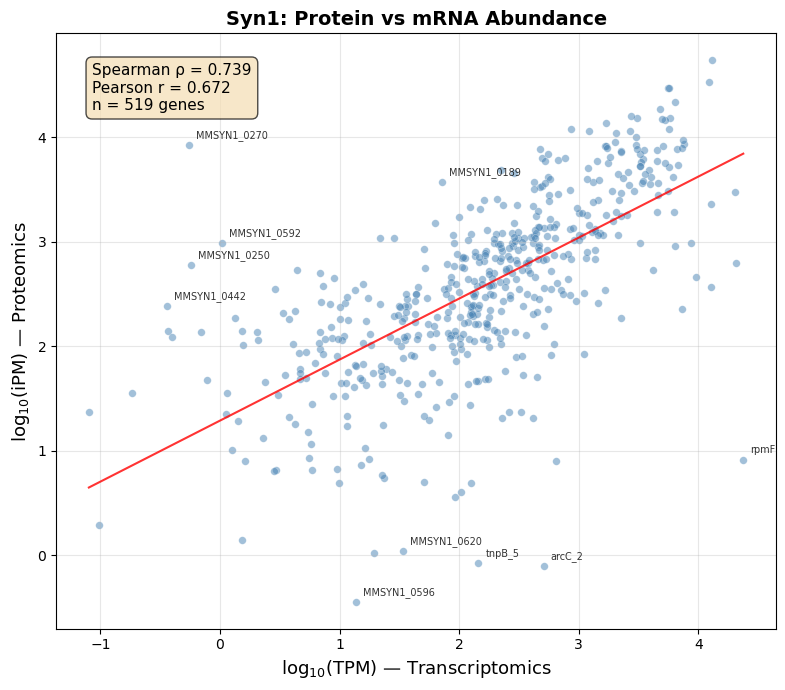

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(corr_df['log10_TPM'], corr_df['log10_iPM'],
           alpha=0.5, s=30, c='steelblue', edgecolors='white', linewidths=0.3)

# Fit line
z = np.polyfit(corr_df['log10_TPM'], corr_df['log10_iPM'], 1)
x_line = np.linspace(corr_df['log10_TPM'].min(), corr_df['log10_TPM'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', linewidth=1.5, alpha=0.8)

ax.set_xlabel('log$_{10}$(TPM) — Transcriptomics', fontsize=13)
ax.set_ylabel('log$_{10}$(iPM) — Proteomics', fontsize=13)
ax.set_title('Syn1: Protein vs mRNA Abundance', fontsize=14, fontweight='bold')
ax.text(0.05, 0.95,
        f'Spearman ρ = {rho:.3f}\nPearson r = {r:.3f}\nn = {len(corr_df)} genes',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', alpha=0.7))

# Label top outliers by residual
corr_df['residual'] = corr_df['log10_iPM'] - np.polyval(z, corr_df['log10_TPM'])
outliers = pd.concat([corr_df.nlargest(5, 'residual'), corr_df.nsmallest(5, 'residual')])
for _, row in outliers.iterrows():
    label = row['gene_name'] if pd.notna(row['gene_name']) else row['locus_tag']
    ax.annotate(label, (row['log10_TPM'], row['log10_iPM']),
                fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('protein_vs_mRNA_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

**Residual analysis to explain deviation**

In [7]:
cols_show = ['locus_tag', 'gene_name', 'gene_product', 'log10_TPM', 'log10_iPM', 'residual']

print('=== Top 15: MORE protein than expected from mRNA ===')
print('(high translational efficiency or stable protein)\n')
display(corr_df.nlargest(15, 'residual')[cols_show].reset_index(drop=True))

print('\n=== Top 15: LESS protein than expected from mRNA ===')
print('(poor translation or rapid degradation or poor proteomics coverage)\n')
display(corr_df.nsmallest(15, 'residual')[cols_show].reset_index(drop=True))

=== Top 15: MORE protein than expected from mRNA ===
(high translational efficiency or stable protein)



,locus_tag,gene_name,gene_product,log10_TPM,log10_iPM,residual
0,MMSYN1_0270,NaN,ATPase_ YjeE family,-0.257118,3.927874,2.789571
1,MMSYN1_0592,NaN,cdsf,0.014058,2.992012,1.695397
2,MMSYN1_0250,NaN,conserved hypothetical protein,-0.238072,2.774312,1.624890
3,MMSYN1_0442,NaN,nitrogen fixation protein nifu,-0.442252,2.380582,1.350360
4,MMSYN1_0189,NaN,conserved hypothetical protein,1.858426,3.572745,1.199392
5,MMSYN1_0443,mthfs,5-formyltetrahydrofolate cyclo-ligase,-0.434034,2.143914,1.108894
6,MMSYN1_0628,argF,ornithine carbamoyltransferase,2.933513,4.075413,1.074426
7,MMSYN1_0580,NaN,conserved hypothetical protein,0.641811,2.729802,1.066706
8,MMSYN1_0151,tuf,translation elongation factor Tu,4.112891,4.734734,1.045228
9,MMSYN1_0190,NaN,leucyl aminopeptidase,2.671462,3.883042,1.035039



=== Top 15: LESS protein than expected from mRNA ===
(poor translation or rapid degradation or poor proteomics coverage)



,locus_tag,gene_name,gene_product,log10_TPM,log10_iPM,residual
0,MMSYN1_0784,arcC_2,carbamate kinase 1,2.705473,-0.101103,-2.968962
1,MMSYN1_0526,rpmF,ribosomal protein L32,4.374972,0.916423,-2.926086
2,MMSYN1_0781,tnpB_5,IS1296 transposase protein B,2.160421,-0.074786,-2.624443
3,MMSYN1_0596,NaN,hypothetical protein,1.141108,-0.443373,-2.397957
4,MMSYN1_0620,NaN,ferric uptake regulator,1.533325,0.044828,-2.138732
5,MMSYN1_0909,rnpA,ribonuclease P protein component,2.807802,0.898008,-2.029589
6,MMSYN1_0730,NaN,conserved hypothetical protein,1.285305,0.024949,-2.013818
7,MMSYN1_0587,NaN,mycoplasma virulence signal region (Myco_arth_...,1.963169,0.555187,-1.879315
8,MMSYN1_0590,NaN,type III restriction enzyme_ res subunit,2.013109,0.603984,-1.859673
9,MMSYN1_0770,NaN,conserved hypothetical protein,2.094828,0.691768,-1.819597
